In [1]:
import torch, torchvision
import torch.nn as nn
import torch.backends.cudnn as cudnn

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from shared import *

set_neurips_style()
cudnn.benchmark = True
plt.ion();

In [2]:
BASE = "cifar10-data"
BASE_PLOTS = os.path.join(BASE, "plots")
BASE_MODELS = os.path.join(BASE, "models")
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
BATCH_SIZE = 64
LR = 0.001
MOMENTUM = 0.9
STEP_SIZE = 7
GAMMA = 0.1
N_EPOCHS = 5

os.makedirs(BASE_PLOTS, exist_ok=True)
os.makedirs(BASE_MODELS, exist_ok=True)
print(f"Using {DEVICE=}")

Using DEVICE='cuda'


# 1. Baseline Setup

In [3]:
def process_fn(inp):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    return inp

def visualize(inputs, classes, dataloader):
    
    n_cols = 5
    n_rows = int(np.ceil(inputs.shape[0] / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5,2.7))
    axes = axes.ravel()
    
    for i, (im, label) in enumerate(zip(inputs, classes)):
        class_name = dataloader.dataset.classes[label].title()
        imshow(im, process_fn, class_name, ax=axes[i])

    sns.despine(left=True, bottom=True)
    fig.tight_layout()

    return fig, axes

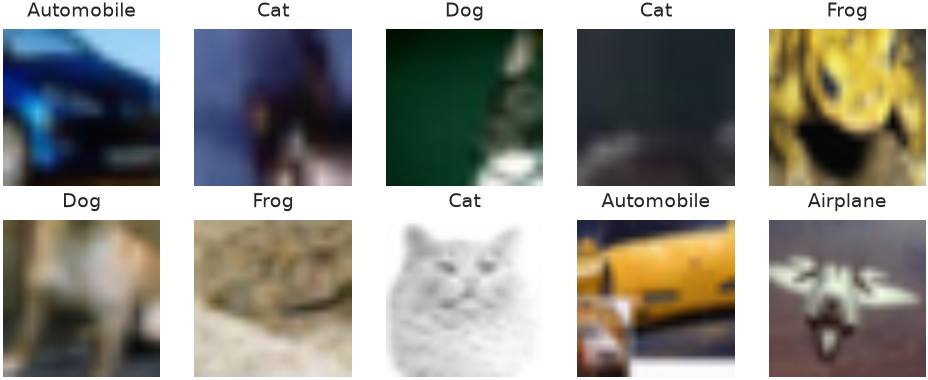

In [4]:
dataloaders, dataset_sizes = load_cifar(batch_size=BATCH_SIZE, num_workers=8)
data_iter = iter(dataloaders["train"])
xb, yb = next(data_iter)

N=10
visualize(xb[:N], yb[:N], dataloaders["train"])
plt.savefig(os.path.join(BASE_PLOTS, "cifar10_samples.pdf"), dpi=300)
plt.show()

In [5]:
def load_model(pretrained=True):
    weights = torchvision.models.ResNet152_Weights.IMAGENET1K_V1 if pretrained else None
    return torchvision.models.resnet152(weights=weights)

def add_clf_head(resnet):
    n_features = resnet.fc.in_features
    resnet.fc = nn.Linear(n_features, 10, bias=True)
    return resnet

In [6]:
model_baseline = add_clf_head(freeze_model(load_model())).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(model_baseline.fc, lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA)

In [7]:
tracker_baseline = GradientTracker(model_baseline)  # for comparison in Part 2

In [8]:
train_model(os.path.join(BASE_MODELS, "cnn-task_baseline"), model_baseline, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

...

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Training complete in 13m 51s
Best val Acc: 0.773600


In [9]:
tracker_baseline.unregister()

In [10]:
baseline_weight_grad_df = pd.DataFrame(tracker_baseline.gradients["fc.weight"])
baseline_weight_grad_df.to_json(os.path.join(BASE, "baseline_weight_gradients.json"), orient="records", lines=True)

In [11]:
model_baseline.load_state_dict(torch.load(os.path.join(BASE_MODELS, f"best_cnn-task_baseline.pt"), weights_only=True))

<All keys matched successfully>

  0%|          | 0/3 [00:00<?, ?it/s]

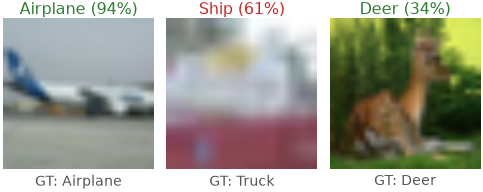

In [27]:
def run_inference(model, image):
    image = image[None].to(DEVICE)
    outputs = model(image)
    confidence, predicted_label = torch.max(F.softmax(outputs, dim=-1), 1)
    return image[0], predicted_label.detach().cpu().tolist()[0], confidence.detach().cpu().tolist()[0]

class_names = dataloaders["train"].dataset.classes
offset = 30
visualize_model(model_baseline, process_fn, [(xb[i], yb[i]) for i in range(offset, offset+3)],
                class_names, run_inference,
                figsize=(3.25, 1.35), ncols=3)
plt.savefig(os.path.join(BASE_PLOTS, "cifar10_inference.pdf"), dpi=300)
plt.show()

In [28]:
del model_baseline
del criterion
del optimizer
del exp_sched

free_mem()

# 2. Residual Connections in Practice

In [29]:
def remove_skip_connections(model):
    def _overriden_forward(self, x):
        out = x
        
        out = self.conv1(out)
        out = self.bn1(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        out = self.conv3(out)
        out = self.bn3(out)

        out = self.relu(out)
        
        return out
    
    for module in model.modules():
        if isinstance(module, torchvision.models.resnet.Bottleneck):
            module.forward = _overriden_forward.__get__(module, torchvision.models.resnet.Bottleneck)
    
    return model

In [30]:
model_no_skip = remove_skip_connections(add_clf_head(freeze_model(load_model()))).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(model_no_skip.fc, lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA)

In [31]:
model_no_skip.layer1

Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (downsample): Sequential(
      (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (1): Bottleneck(
    (conv1): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, t

In [32]:
tracker_no_skip = GradientTracker(model_no_skip)  # for comparison with baseline

In [33]:
train_model(os.path.join(BASE_MODELS, "cnn-task_no-skip"), model_no_skip, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

...

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Training complete in 10m 48s
Best val Acc: 0.110300


In [34]:
tracker_no_skip.unregister()

In [35]:
no_skip_weight_grad_df = pd.DataFrame(tracker_no_skip.gradients["fc.weight"])
no_skip_weight_grad_df.to_json(os.path.join(BASE, "no_skip_weight_gradients.json"), orient="records", lines=True)

In [36]:
baseline_weight_grad_df = pd.read_json(os.path.join(BASE, "baseline_weight_gradients.json"), orient="records", lines=True)
no_skip_weight_grad_df = pd.read_json(os.path.join(BASE, "no_skip_weight_gradients.json"), orient="records", lines=True)

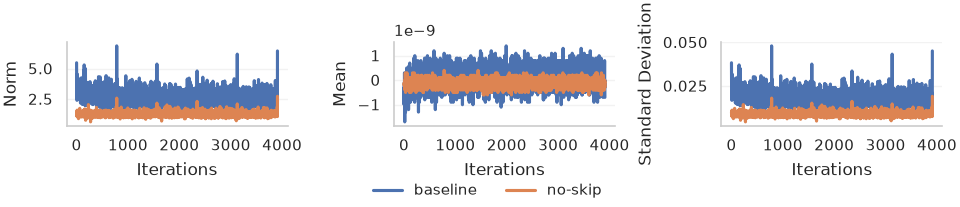

In [37]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(6.5, 1.35))

for (perf_df, label) in [
    (baseline_weight_grad_df, "baseline"),
    (no_skip_weight_grad_df, "no-skip"),
]:
    lineplot_kwargs = dict(linewidth=1.5, markersize=0, label=label)
    configs = [
        {
            "column": "norm",
            "title": "",
            "xlabel": "Iterations",
            "ylabel": "Norm",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax1},
        },
        {
            "column": "mean",
            "title": "",
            "xlabel": "Iterations",
            "ylabel": "Mean",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax2},
        },
        {
            "column": "std",
            "title": "",
            "xlabel": "Iterations",
            "ylabel": "Standard Deviation",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax3},
        },
    ]
    
    plot_line(perf_df, configs)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=7,
    bbox_to_anchor=(0.5, -0.01),
)

for ax in [ax1, ax2, ax3]:
    ax.grid(axis="y", alpha=0.25, linewidth=0.7)
    ax.grid(axis="x", visible=False)
    # ax.legend(title="", frameon=False, loc="best")
    ax.legend_.remove()
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(1_000))

fig.tight_layout(rect=[0, 0.06, 1, 1])

plt.savefig(os.path.join(BASE_PLOTS, "cifar10_gradients.pdf"), dpi=300)
plt.show()

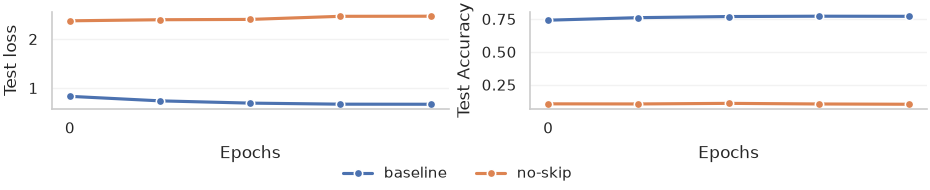

In [43]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(6.5, 1.35))

for i, fname in enumerate(["cnn-task_baseline", "cnn-task_no-skip"]):
    with open(os.path.join(BASE_MODELS, f"{fname}.json"), "r") as f:
        perf = json.loads(f.read())

    perf_df = pd.DataFrame(perf["val"])
    label = fname.split("_")[-1]
    lineplot_kwargs = dict(label=label, linewidth=1.5)
    
    configs = [
        {
            "column": "loss",
            "title": "",
            "xlabel": "Epochs",
            "ylabel": "Test loss",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax1},
        },

        {
            "column": "accuracy",
            "title": "",
            "xlabel": "Epochs",
            "ylabel": "Test Accuracy",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax2},
        },
    ]
    
    plot_line(perf_df, configs)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=7,
    bbox_to_anchor=(0.5, -0.01),
)

for ax in [ax1, ax2]:
    ax.grid(axis="y", alpha=0.25, linewidth=0.7)
    ax.grid(axis="x", visible=False)
    ax.legend_.remove()
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(1_000))

fig.tight_layout(rect=[0, 0.06, 1, 1])

plt.savefig(os.path.join(BASE_PLOTS, "baseline-vs-no-skip.pdf"), bbox_inches="tight", dpi=300)
plt.show()

In [39]:
del model_no_skip
del criterion
del optimizer
del exp_sched

free_mem()